In [5]:
import numpy as np
import matplotlib.pyplot as plt
import import_ipynb
from body import Body
from simulation import compute_forces

Final Positions:
Sun: [ 143914.2994073  3078985.02379346] meters
Earth: [1.49599690e+11 3.09995928e+08] meters
Mars: [-2.20055701e+11 -5.04041384e+10] meters


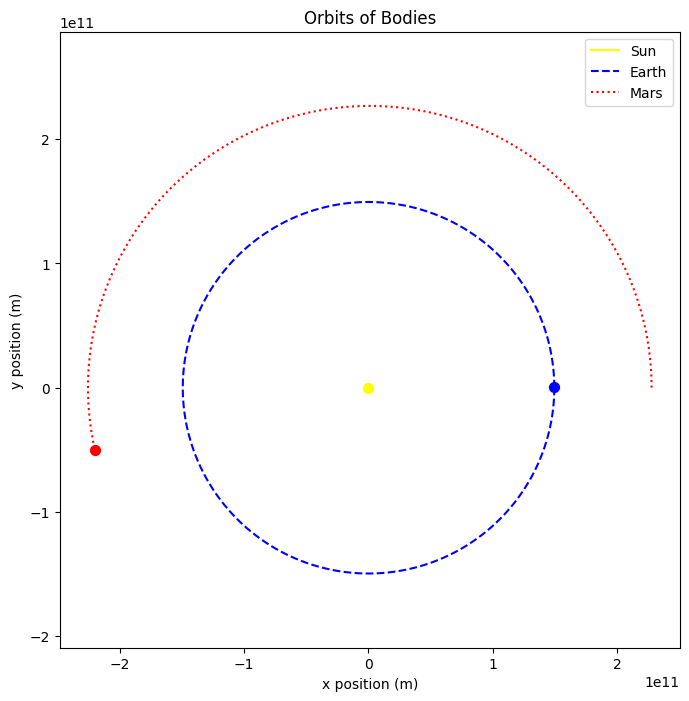

In [ ]:
def main():
    # ---------------------------
    # 1. Create bodies
    # ---------------------------
    sun = Body(
        name = "Sun",
        mass = 1.989e30, #kg
        position = [0,0], # meters
        velocity = [0,0], #m/s
        color = "yellow"
    )
    
    earth = Body(
    name="Earth",
    mass=5.972e24,               # kg
    position=[1.496e11, 0],      # 1 AU in meters
    velocity=[0, 29780],         # m/s (orbital speed)
    color="blue"
    )
    
    mars = Body(
        name="Mars",
        mass=6.39e23,                # kg
        position=[2.279e11, 0],      # meters
        velocity=[0, 24077],         # m/s
        color="red"
    )

    bodies = [sun, earth, mars]

    # ---------------------------
    # 2. Simulation parameters
    # ---------------------------
    dt = 1*60*60 # 1 hour time step in seconds
    steps = 24*365 # simulating 1 year hourly
    
    # ---------------------------
    # 3. Run simulation
    # ---------------------------
    
    for step in range(steps):
        compute_forces(bodies)
        for body in bodies:
            body.update_velocity(dt)
            body.update_position(dt)
            
    # ---------------------------
    # 4. Print final positions
    # ---------------------------
    print("Final Positions:")
    for body in bodies:
        print(f"{body.name}: {body.position} meters")
    
    # ---------------------------
    # 5. Plotting the Orbits
    # ---------------------------

    plt.figure(figsize=(8,8))  # create one figure

    # choose line styles for each body
    styles = {'Sun':'-', 'Earth':'--', 'Mars':':'}

    for body in bodies:
        trail = np.array(body.trail)
        plt.plot(trail[:,0], trail[:,1], 
                 label=body.name, 
                 color=body.color, 
                 linestyle=styles.get(body.name, '-')) 
        plt.scatter(trail[-1,0], trail[-1,1], color=body.color, s=50)  # mark final position

    plt.xlabel("x position (m)")
    plt.ylabel("y position (m)")
    plt.title("Orbits of Bodies")
    plt.legend()
    plt.axis("equal")
    plt.show() 

if __name__ == "__main__":
    main()